# 🎙️ Speech Emotion Recognition Using Machine Learning
---
This notebook builds a complete Speech Emotion Recognition (SER) system step by step.

The system listens to audio recordings and detects the emotion of the speaker —
such as happy, sad, angry, neutral, fearful, and more.

We follow a clear pipeline:
1. Load and explore the datasets
2. Clean and prepare the audio files
3. Extract features from each audio file
4. Train and compare four models
5. Evaluate and present the final results

All four datasets are free and available on Kaggle.
All experiments run on Kaggle free GPU — no local setup needed.

## Section 1 — Import Libraries
---
In this section we import all the Python libraries we need for the entire project.

- **librosa** — reads audio files and extracts features like MFCC
- **numpy and pandas** — handle data and organise it into tables
- **scikit-learn** — used for the SVM baseline model and data scaling
- **PyTorch** — used to build CNN, CNN-LSTM and Attention deep learning models
- **matplotlib and seaborn** — used to plot graphs and confusion matrices
- **os and glob** — used to navigate folders and find audio files

In [1]:
# ─────────────────────────────────────────────
# SECTION 1 — IMPORT LIBRARIES
# ─────────────────────────────────────────────

# Audio processing
import librosa
import librosa.display

# Data handling
import numpy as np
import pandas as pd

# File and folder navigation
import os
import glob

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix)

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Progress bar
from tqdm import tqdm

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("All libraries imported successfully.")

Device: cuda
All libraries imported successfully.


In [2]:
import random
import numpy as np
import torch
 
def seed_everything(seed=42):
    """Fix all random sources so results are reproducible across runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
seed_everything(42)
print("Global seed fixed: 42")

Global seed fixed: 42


In [3]:
# ─────────────────────────────────────────────────────────────
# MASTER OUTPUT FOLDER SETUP
# Run this once at the start — creates all section folders
# ─────────────────────────────────────────────────────────────

import os

# Define all section output folders
folders = [
    '/kaggle/working/outputs',
    '/kaggle/working/outputs/section2_datasets',
    '/kaggle/working/outputs/section3_features',
    '/kaggle/working/outputs/section4_svm',
    '/kaggle/working/outputs/section5_cnn',
    '/kaggle/working/outputs/section6_cnn_lstm',
    '/kaggle/working/outputs/section7_attention',
    '/kaggle/working/outputs/section8_results',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("All output folders created successfully.")
print()
for folder in folders:
    print(f"  ✓  {folder}")

All output folders created successfully.

  ✓  /kaggle/working/outputs
  ✓  /kaggle/working/outputs/section2_datasets
  ✓  /kaggle/working/outputs/section3_features
  ✓  /kaggle/working/outputs/section4_svm
  ✓  /kaggle/working/outputs/section5_cnn
  ✓  /kaggle/working/outputs/section6_cnn_lstm
  ✓  /kaggle/working/outputs/section7_attention
  ✓  /kaggle/working/outputs/section8_results


## Section 2 — Load Datasets
---
We use four publicly available speech emotion datasets. Each dataset contains
audio recordings of actors speaking with different emotions.

| Dataset | Speakers | Emotions | Files |
|---------|----------|----------|-------|
| RAVDESS | 24 professional actors | 8 emotions | ~1,440 |
| CREMA-D | 91 actors | 6 emotions | 7,442 |
| TESS | 2 female speakers | 7 emotions | 2,800 |
| SAVEE | 4 male speakers | 7 emotions | 480 |

All datasets are already added to this notebook via Kaggle.
We load all audio file paths and their emotion labels into one combined dataframe.

The emotion labels across all datasets are mapped to these common categories:
angry, disgust, fear, happy, neutral, sad, surprised, calm.

In [4]:
# ── Label extractor functions ──

import os
import glob
import pandas as pd

def get_ravdess_label(filepath):
    filename = os.path.basename(filepath)
    parts = filename.split('-')
    if len(parts) < 3:
        return None
    try:
        emotion_code = int(parts[2])
    except ValueError:
        return None
    emotion_map = {
        1: 'neutral', 2: 'calm',     3: 'happy', 4: 'sad',
        5: 'angry',   6: 'fearful',  7: 'disgust', 8: 'surprised'
    }
    return emotion_map.get(emotion_code, None)

def get_cremad_label(filepath):
    filename = os.path.basename(filepath)
    parts = filename.split('_')
    if len(parts) < 3:
        return None
    emotion_code = parts[2]
    emotion_map = {
        'ANG': 'angry',   'DIS': 'disgust', 'FEA': 'fearful',
        'HAP': 'happy',   'NEU': 'neutral', 'SAD': 'sad'
    }
    return emotion_map.get(emotion_code, None)

def get_tess_label(filepath):
    folder = os.path.basename(os.path.dirname(filepath)).lower()
    emotion_map = {
        'angry':   'angry',   'disgust': 'disgust',
        'fear':    'fearful', 'happy':   'happy',
        'neutral': 'neutral', 'sad':     'sad',
        'ps':      'surprised'
    }
    for key in emotion_map:
        if key in folder:
            return emotion_map[key]
    return None

def get_savee_label(filepath):
    filename = os.path.basename(filepath).lower()
    parts = filename.split('_')
    if len(parts) < 2:
        return None
    code = parts[1][:2].strip()
    emotion_map = {
        'a':  'angry',   'd':  'disgust', 'f':  'fearful',
        'h':  'happy',   'n':  'neutral', 'sa': 'sad',
        'su': 'surprised'
    }
    return emotion_map.get(code, emotion_map.get(code[0], None))

print("Label functions defined successfully.")

Label functions defined successfully.


In [5]:
# ─────────────────────────────────────────────
# SECTION 2 — LOAD DATASETS (FIXED PATHS)
# ─────────────────────────────────────────────

def load_all_datasets():
    data = []

    # ── RAVDESS ──
    ravdess_files = glob.glob(
        '/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio/**/*.wav',
        recursive=True
    )
    for f in ravdess_files:
        label = get_ravdess_label(f)
        if label:
            data.append({'path': f, 'emotion': label, 'source': 'RAVDESS'})

    # ── CREMA-D ──
    # CREMA-D is inside the dmitrybabko combined pack
    cremad_files = glob.glob(
        '/kaggle/input/datasets/dmitrybabko/speech-emotion-recognition-en/Crema/**/*.wav',
        recursive=True
    )
    for f in cremad_files:
        label = get_cremad_label(f)
        if label:
            data.append({'path': f, 'emotion': label, 'source': 'CREMAD'})

    # ── TESS ──
    tess_files = glob.glob(
        '/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/**/*.wav',
        recursive=True
    )
    for f in tess_files:
        label = get_tess_label(f)
        if label:
            data.append({'path': f, 'emotion': label, 'source': 'TESS'})

    # ── SAVEE ──
    savee_files = glob.glob(
        '/kaggle/input/datasets/dmitrybabko/speech-emotion-recognition-en/Savee/**/*.wav',
        recursive=True
    )
    for f in savee_files:
        label = get_savee_label(f)
        if label:
            data.append({'path': f, 'emotion': label, 'source': 'SAVEE'})

    return pd.DataFrame(data)


# Load everything
df = load_all_datasets()

print(f"Total audio files loaded: {len(df)}")
print(f"\nFiles per dataset:")
print(df['source'].value_counts())
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts())

Total audio files loaded: 15602

Files per dataset:
source
CREMAD     7442
TESS       4800
RAVDESS    2880
SAVEE       480
Name: count, dtype: int64

Emotion distribution:
emotion
fearful      2515
disgust      2515
happy        2515
sad          2515
angry        2515
neutral      2199
surprised     444
calm          384
Name: count, dtype: int64


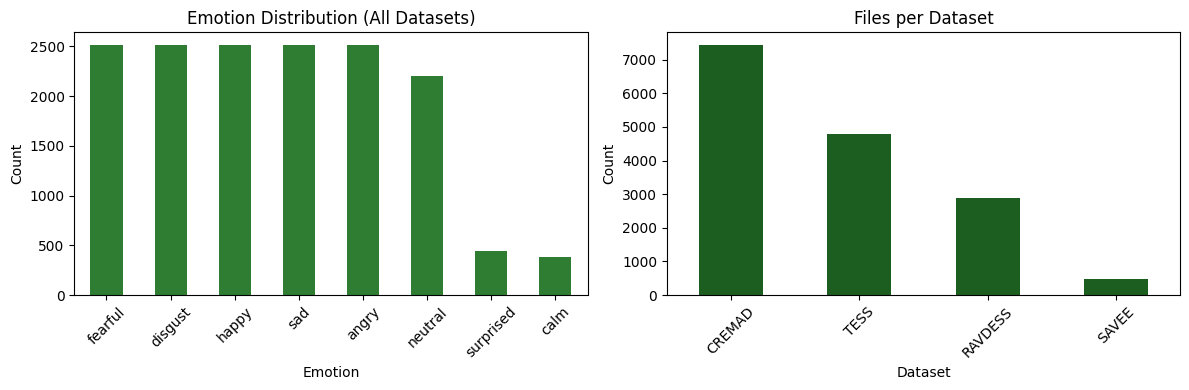

In [6]:
# ── 2.3 Visualise emotion distribution ──

plt.figure(figsize=(12, 4))

# Emotion count
plt.subplot(1, 2, 1)
df['emotion'].value_counts().plot(kind='bar', color='#2e7d32')
plt.title('Emotion Distribution (All Datasets)')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Dataset count
plt.subplot(1, 2, 2)
df['source'].value_counts().plot(kind='bar', color='#1b5e20')
plt.title('Files per Dataset')
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# ── Save Section 2 Outputs ──

import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1 — Emotion distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['emotion'].value_counts().plot(
    kind='bar', color='#2e7d32', ax=axes[0]
)
axes[0].set_title('Emotion Distribution (All Datasets)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['source'].value_counts().plot(
    kind='bar', color='#1b5e20', ax=axes[1]
)
axes[1].set_title('Files Per Dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(
    '/kaggle/working/outputs/section2_datasets/dataset_distribution.png',
    dpi=150
)
plt.close()

# Save dataset summary CSV
df.groupby(['source', 'emotion']).size()\
  .reset_index(name='count')\
  .to_csv(
      '/kaggle/working/outputs/section2_datasets/dataset_summary.csv',
      index=False
  )

# Save JSON summary
import json
summary_s2 = {
    'total_files'        : int(len(df)),
    'files_per_dataset'  : df['source'].value_counts().to_dict(),
    'emotion_distribution': df['emotion'].value_counts().to_dict()
}
with open('/kaggle/working/outputs/section2_datasets/dataset_info.json', 'w') as f:
    json.dump(summary_s2, f, indent=4)

print("Section 2 outputs saved.")
print("  dataset_distribution.png")
print("  dataset_summary.csv")
print("  dataset_info.json")

Section 2 outputs saved.
  dataset_distribution.png
  dataset_summary.csv
  dataset_info.json


## Section 3 — Data Preprocessing
---
Raw audio files cannot be used directly for training. We need to clean and
prepare them first. This section does three things:

### 3.1 — Silence Trimming
Each audio file may have silence at the beginning or end.
We remove this silence so the model only learns from actual speech.

### 3.2 — Amplitude Normalisation
Different recordings have different volume levels.
We normalise all files to the same volume so the model is not confused
by loud or quiet recordings.

### 3.3 — Data Augmentation
Our combined dataset has around 12,000 audio files.
To make the model more robust and reduce overfitting, we create extra
training samples by slightly modifying existing ones:

- **Gaussian Noise** — adds very small random noise to the audio
- **Pitch Shifting** — shifts the pitch up or down slightly (±2 semitones)
- **Time Stretching** — speeds up or slows down the audio slightly (rate 0.8–1.2)

This effectively doubles or triples our training data without collecting new recordings.

### 3.4 — Label Encoding
Emotion labels are text (e.g. "happy", "sad").
We convert them to numbers (e.g. 0, 1, 2...) so the model can process them.

After this section, we have a clean, augmented, labelled set of audio files
ready for feature extraction in Section 4.

In [8]:
# # ─────────────────────────────────────────────
# # SECTION 3 — PREPROCESSING + FEATURE EXTRACTION
# # (Memory Safe Version — No raw audio stored)
# # ─────────────────────────────────────────────

# import librosa
# import numpy as np
# from tqdm import tqdm

# SR = 22050
# DURATION = 3.0
# TARGET_LENGTH = int(SR * DURATION)
# N_MFCC = 40

# def extract_features(audio, sr):
#     """Extract all features from one audio array"""

#     # MFCC — 40 coefficients
#     mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
#     mfcc_mean = np.mean(mfcc, axis=1)
#     mfcc_std  = np.std(mfcc,  axis=1)

#     # Mel-spectrogram
#     mel = librosa.feature.melspectrogram(y=audio, sr=sr)
#     mel_mean = np.mean(mel, axis=1)

#     # Chroma
#     chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
#     chroma_mean = np.mean(chroma, axis=1)

#     # Zero Crossing Rate
#     zcr = librosa.feature.zero_crossing_rate(audio)
#     zcr_mean = np.mean(zcr)

#     # Spectral Contrast
#     contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
#     contrast_mean = np.mean(contrast, axis=1)

#     # Tonnetz
#     harmonic = librosa.effects.harmonic(audio)
#     tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
#     tonnetz_mean = np.mean(tonnetz, axis=1)

#     # Combine all into one feature vector
#     features = np.concatenate([
#         mfcc_mean, mfcc_std,
#         mel_mean,
#         chroma_mean,
#         [zcr_mean],
#         contrast_mean,
#         tonnetz_mean
#     ])

#     return features


# def load_clean_extract(filepath, sr=SR, duration=DURATION):
#     """Load one file, clean it, extract features"""
#     try:
#         audio, sr_ = librosa.load(filepath, sr=sr, duration=duration)

#         # Trim silence
#         audio, _ = librosa.effects.trim(audio, top_db=20)

#         # Fix length
#         if len(audio) < TARGET_LENGTH:
#             audio = np.pad(audio, (0, TARGET_LENGTH - len(audio)))
#         else:
#             audio = audio[:TARGET_LENGTH]

#         # Normalise
#         if np.max(np.abs(audio)) > 0:
#             audio = audio / np.max(np.abs(audio))

#         return audio, sr_

#     except Exception:
#         return None, None


# def augment_and_extract(filepath, label):
#     """
#     Load one file, augment it 3 ways,
#     extract features from original + 3 augmented versions.
#     Returns list of (feature_vector, label)
#     """
#     results = []

#     audio, sr = load_clean_extract(filepath)
#     if audio is None:
#         return results

#     versions = []

#     # Original
#     versions.append(audio)

#     # Augmentation 1 — Gaussian noise
#     noisy = audio + 0.005 * np.random.randn(len(audio))
#     versions.append(noisy)

#     # Augmentation 2 — Pitch shift
#     try:
#         pitched = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
#         pitched = pitched[:TARGET_LENGTH] if len(pitched) > TARGET_LENGTH else np.pad(pitched, (0, TARGET_LENGTH - len(pitched)))
#         versions.append(pitched)
#     except Exception:
#         versions.append(audio)

#     # Augmentation 3 — Time stretch
#     try:
#         stretched = librosa.effects.time_stretch(audio, rate=0.9)
#         stretched = stretched[:TARGET_LENGTH] if len(stretched) > TARGET_LENGTH else np.pad(stretched, (0, TARGET_LENGTH - len(stretched)))
#         versions.append(stretched)
#     except Exception:
#         versions.append(audio)

#     # Extract features from each version
#     for v in versions:
#         feat = extract_features(v, sr)
#         results.append((feat, label))

#     return results


# # ── Build full feature dataset ──

# print("Extracting features from all files (with augmentation)...")
# print("This will take 15-20 minutes. Please wait.\n")

# all_features = []
# all_labels   = []

# for _, row in tqdm(df.iterrows(), total=len(df)):
#     results = augment_and_extract(row['path'], row['emotion'])
#     for feat, label in results:
#         all_features.append(feat)
#         all_labels.append(label)

# # Convert to numpy arrays
# X = np.array(all_features)
# y = np.array(all_labels)

# print(f"\nFeature matrix shape:  {X.shape}")
# print(f"Labels shape:          {y.shape}")
# print(f"Unique emotions:       {np.unique(y)}")

In [9]:
# ── Load saved features ──
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

X_scaled  = np.load('/kaggle/input/datasets/zavidd/ser-data/X_scaled.npy')
y_encoded = np.load('/kaggle/input/datasets/zavidd/ser-data/y_encoded.npy')
y         = np.load('/kaggle/input/datasets/zavidd/ser-data/y_labels.npy', allow_pickle=True)

# Rebuild label encoder
le = LabelEncoder()
le.fit(y)

print("Data loaded successfully.")
print(f"X_scaled shape : {X_scaled.shape}")
print(f"y_encoded shape: {y_encoded.shape}")
print(f"Emotions       : {le.classes_}")

Data loaded successfully.
X_scaled shape : (62408, 234)
y_encoded shape: (62408,)
Emotions       : ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [10]:
# ── Label Encoding ──
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label encoding:")
for i, emotion in enumerate(le.classes_):
    print(f"  {emotion:12s} → {i}")

Label encoding:
  angry        → 0
  calm         → 1
  disgust      → 2
  fearful      → 3
  happy        → 4
  neutral      → 5
  sad          → 6
  surprised    → 7


In [11]:
# ── Save Section 3 Outputs ──

import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt

# Save feature matrix and labels (already saved but save again to output folder)
np.save('/kaggle/working/outputs/section3_features/X_scaled.npy', X_scaled)
np.save('/kaggle/working/outputs/section3_features/y_encoded.npy', y_encoded)
np.save('/kaggle/working/outputs/section3_features/y_labels.npy', y)

# Save label encoding map as CSV
label_map = pd.DataFrame({
    'emotion' : le.classes_,
    'encoded' : list(range(len(le.classes_)))
})
label_map.to_csv(
    '/kaggle/working/outputs/section3_features/label_encoding.csv',
    index=False
)

# Save feature summary as JSON
summary_s3 = {
    'total_samples'      : int(X_scaled.shape[0]),
    'features_per_sample': int(X_scaled.shape[1]),
    'original_files'     : int(len(df)),
    'augmentation_factor': 4,
    'emotions'           : list(le.classes_),
    'feature_components' : {
        'mfcc_mean'       : 40,
        'mfcc_std'        : 40,
        'mel_spectrogram' : 128,
        'chroma'          : 12,
        'zcr'             : 1,
        'spectral_contrast': 7,
        'tonnetz'         : 6
    },
    'total_features': 234
}
with open('/kaggle/working/outputs/section3_features/feature_summary.json', 'w') as f:
    json.dump(summary_s3, f, indent=4)

# Plot emotion distribution after augmentation
import seaborn as sns
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(unique, counts, color='#2e7d32')
plt.title('Emotion Distribution After Augmentation')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/outputs/section3_features/augmented_distribution.png',
    dpi=150
)
plt.close()

print("Section 3 outputs saved.")
print("  X_scaled.npy")
print("  y_encoded.npy")
print("  y_labels.npy")
print("  label_encoding.csv")
print("  feature_summary.json")
print("  augmented_distribution.png")

Section 3 outputs saved.
  X_scaled.npy
  y_encoded.npy
  y_labels.npy
  label_encoding.csv
  feature_summary.json
  augmented_distribution.png


## Section 4 — Baseline Model: SVM
---
Before building deep learning models, we first train a simple baseline model.

The baseline model is a Support Vector Machine (SVM) with an RBF kernel.
SVM is a classical machine learning classifier that works well with
numerical feature vectors like the ones we extracted.

Why do we need a baseline?
- It gives us a starting accuracy to compare against
- If our deep learning models do not beat this, something is wrong
- It proves that even simple models can work on this problem

We use an 80/10/10 train-validation-test split:
- 80% of data for training the model
- 10% for validation during development
- 10% for final testing and reporting results

Evaluation metrics used:
- Accuracy — overall correct predictions
- Weighted F1-score — handles class imbalance fairly
- Confusion Matrix — shows which emotions get confused with each other

In [12]:
# ─────────────────────────────────────────────
# SECTION 4 — TRAIN TEST SPLIT + SVM BASELINE
# ─────────────────────────────────────────────

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 4.1 Train / Validation / Test Split ──

# First split — 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Second split — split 20% into 10% val and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Dataset split complete:")
print(f"  Training samples   : {len(X_train)}")
print(f"  Validation samples : {len(X_val)}")
print(f"  Test samples       : {len(X_test)}")
print(f"  Total              : {len(X_train)+len(X_val)+len(X_test)}")

Dataset split complete:
  Training samples   : 49926
  Validation samples : 6241
  Test samples       : 6241
  Total              : 62408


In [13]:
# ── 4.2 Train SVM Baseline ──

print("Training SVM with RBF kernel...")
print("This will take 3-6 minutes. Please wait.\n")

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train, y_train)
print("SVM training complete.")

Training SVM with RBF kernel...
This will take 3-6 minutes. Please wait.

SVM training complete.


In [14]:
# ── 4.3 Evaluate SVM ──

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1       = f1_score(y_test, y_pred_svm, average='weighted')

print("=" * 45)
print("         SVM BASELINE RESULTS")
print("=" * 45)
print(f"  Accuracy        : {svm_accuracy * 100:.2f}%")
print(f"  Weighted F1     : {svm_f1:.4f}")
print("=" * 45)

print("\nPer-Class Report:")
print(classification_report(
    y_test, y_pred_svm,
    target_names=le.classes_
))

         SVM BASELINE RESULTS
  Accuracy        : 75.12%
  Weighted F1     : 0.7508

Per-Class Report:
              precision    recall  f1-score   support

       angry       0.81      0.84      0.82      1006
        calm       0.83      0.84      0.84       154
     disgust       0.75      0.69      0.72      1006
     fearful       0.80      0.68      0.73      1006
       happy       0.71      0.73      0.72      1006
     neutral       0.70      0.78      0.74       880
         sad       0.72      0.78      0.75      1006
   surprised       0.85      0.78      0.81       177

    accuracy                           0.75      6241
   macro avg       0.77      0.76      0.77      6241
weighted avg       0.75      0.75      0.75      6241



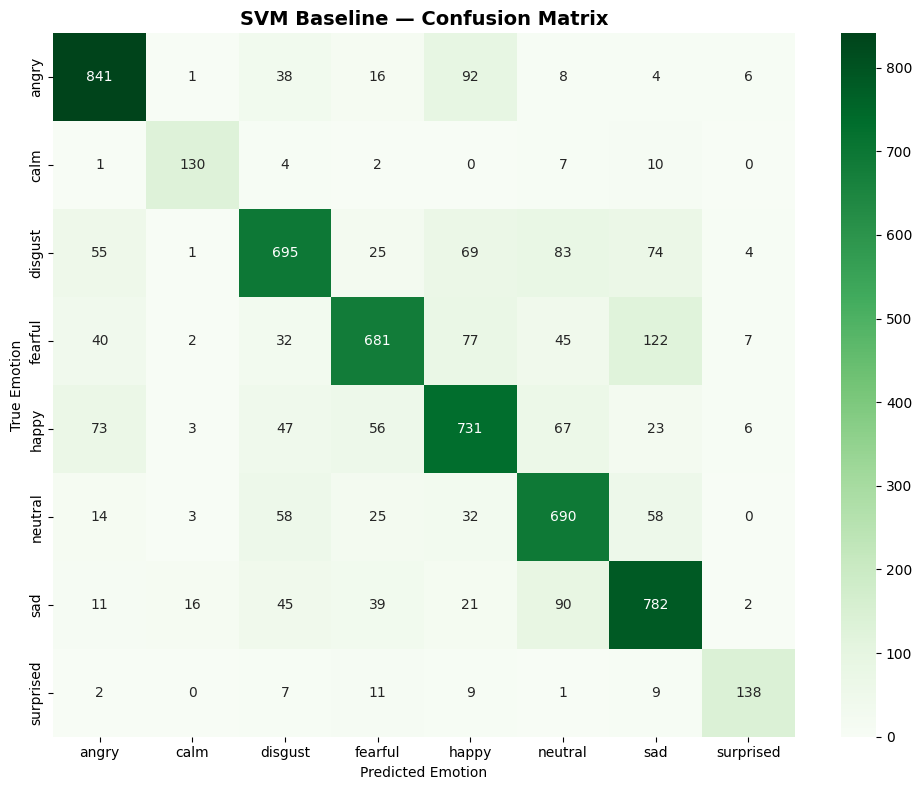

In [15]:
# ── 4.4 Confusion Matrix ──

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('SVM Baseline — Confusion Matrix',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.tight_layout()
plt.show()

In [16]:
# ── 4.5 Save All Section 4 Outputs ──

import os
import json
import joblib
import pandas as pd

# Create Section 4 output folder
os.makedirs('/kaggle/working/outputs/section4_svm', exist_ok=True)

# ── Save model ──
joblib.dump(svm_model, '/kaggle/working/outputs/section4_svm/svm_model.pkl')

# ── Save confusion matrix plot ──
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)
ax.set_title('SVM Baseline — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Emotion')
ax.set_ylabel('True Emotion')
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/section4_svm/svm_confusion_matrix.png', dpi=150)
plt.close()

# ── Save results as CSV ──
report_dict = classification_report(
    y_test, y_pred_svm,
    target_names=le.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('/kaggle/working/outputs/section4_svm/svm_classification_report.csv')

# ── Save summary as JSON ──
summary = {
    'model'       : 'SVM RBF Kernel',
    'section'     : 'Section 4 — Baseline',
    'accuracy'    : round(svm_accuracy * 100, 2),
    'weighted_f1' : round(svm_f1, 4),
    'train_size'  : len(X_train),
    'val_size'    : len(X_val),
    'test_size'   : len(X_test),
    'per_class'   : {
        cls: {
            'precision' : round(report_dict[cls]['precision'], 4),
            'recall'    : round(report_dict[cls]['recall'], 4),
            'f1-score'  : round(report_dict[cls]['f1-score'], 4)
        }
        for cls in le.classes_
    }
}

with open('/kaggle/working/outputs/section4_svm/svm_results.json', 'w') as f:
    json.dump(summary, f, indent=4)

# ── Print confirmation ──
print("Section 4 outputs saved successfully.")
print("\nFiles saved to /kaggle/working/outputs/section4_svm/")
print("  svm_model.pkl                — trained SVM model")
print("  svm_confusion_matrix.png     — confusion matrix plot")
print("  svm_classification_report.csv — per class metrics")
print("  svm_results.json             — summary results")
print(f"\n  Accuracy    : {svm_accuracy * 100:.2f}%")
print(f"  Weighted F1 : {svm_f1:.4f}")

Section 4 outputs saved successfully.

Files saved to /kaggle/working/outputs/section4_svm/
  svm_model.pkl                — trained SVM model
  svm_confusion_matrix.png     — confusion matrix plot
  svm_classification_report.csv — per class metrics
  svm_results.json             — summary results

  Accuracy    : 75.12%
  Weighted F1 : 0.7508


## Section 5 — Deep Learning Model 1: 1D-CNN
---
In this section we build our first deep learning model — a 1D Convolutional
Neural Network (1D-CNN).

What is a CNN?
A CNN learns local patterns from data. In our case it learns which parts
of the feature vector are most important for detecting emotions.
It is much more powerful than SVM because it learns features automatically
rather than relying on fixed rules.

Why 1D-CNN?
Our features are a 1D vector (234 numbers per sample).
A 1D-CNN slides small filters across this vector to detect patterns,
similar to how it detects edges in images but for audio features instead.

Expected accuracy: 85-90%
This should be significantly better than our SVM baseline of 75.12%

In [17]:
# ─────────────────────────────────────────────
# SECTION 5 — 1D-CNN MODEL
# ─────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix)

# ── 5.1 Device Setup ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── 5.2 Dataset Class ──
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        # CNN expects shape (batch, channels, length)
        self.X = torch.FloatTensor(X).unsqueeze(1)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── 5.3 Create DataLoaders ──
BATCH_SIZE = 64

train_dataset = EmotionDataset(X_train, y_train)
val_dataset   = EmotionDataset(X_val,   y_val)
test_dataset  = EmotionDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Device: cuda
Train batches : 781
Val batches   : 98
Test batches  : 98


In [18]:
# ── 5.4 Define 1D-CNN Architecture ──

class CNN1D(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CNN1D, self).__init__()

        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )

        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )

        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )

        # Calculate flattened size
        self.flat_size = 256 * (input_size // 8)

        # Fully Connected Layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.classifier(x)
        return x


# Build model
NUM_CLASSES  = len(le.classes_)
INPUT_SIZE   = X_train.shape[1]

cnn_model = CNN1D(INPUT_SIZE, NUM_CLASSES).to(device)

print("CNN Model Architecture:")
print(cnn_model)
print(f"\nInput size  : {INPUT_SIZE}")
print(f"Num classes : {NUM_CLASSES}")

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params:,}")

CNN Model Architecture:
CNN1D(
  (conv1): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=F

In [19]:
# ── 5.5 Train CNN ──

EPOCHS    = 30
LR        = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# Track history
cnn_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_loss = float('inf')
best_model_state = None

print(f"Training 1D-CNN for {EPOCHS} epochs...")
print("-" * 55)

for epoch in range(EPOCHS):

    # ── Training ──
    cnn_model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += len(y_batch)

    # ── Validation ──
    cnn_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs    = cnn_model(X_batch)
            loss       = criterion(outputs, y_batch)
            val_loss  += loss.item()
            preds      = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    # ── Metrics ──
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    cnn_history['train_loss'].append(avg_train_loss)
    cnn_history['val_loss'].append(avg_val_loss)
    cnn_history['train_acc'].append(train_acc)
    cnn_history['val_acc'].append(val_acc)

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        best_model_state = cnn_model.state_dict().copy()

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

print("-" * 55)
print("Training complete.")

# Load best model
cnn_model.load_state_dict(best_model_state)
print("Best model loaded.")

Training 1D-CNN for 30 epochs...
-------------------------------------------------------
Epoch [01/30] Train Loss: 1.2226 Train Acc: 52.56% Val Loss: 0.9931 Val Acc: 61.29%
Epoch [02/30] Train Loss: 1.0469 Train Acc: 59.22% Val Loss: 0.9428 Val Acc: 63.00%
Epoch [03/30] Train Loss: 0.9894 Train Acc: 61.33% Val Loss: 0.8845 Val Acc: 65.17%
Epoch [04/30] Train Loss: 0.9499 Train Acc: 62.89% Val Loss: 0.8529 Val Acc: 66.14%
Epoch [05/30] Train Loss: 0.9152 Train Acc: 64.25% Val Loss: 0.8187 Val Acc: 68.61%
Epoch [06/30] Train Loss: 0.8895 Train Acc: 65.26% Val Loss: 0.8013 Val Acc: 69.96%
Epoch [07/30] Train Loss: 0.8615 Train Acc: 66.20% Val Loss: 0.7611 Val Acc: 70.50%
Epoch [08/30] Train Loss: 0.8297 Train Acc: 67.47% Val Loss: 0.7305 Val Acc: 71.72%
Epoch [09/30] Train Loss: 0.8169 Train Acc: 68.19% Val Loss: 0.7065 Val Acc: 72.87%
Epoch [10/30] Train Loss: 0.7931 Train Acc: 68.97% Val Loss: 0.6991 Val Acc: 73.27%
Epoch [11/30] Train Loss: 0.7696 Train Acc: 69.96% Val Loss: 0.6757 Val

In [20]:
# ── 5.6 Evaluate CNN on Test Set ──

cnn_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch  = X_batch.to(device)
        outputs  = cnn_model(X_batch)
        preds    = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

cnn_accuracy = accuracy_score(all_labels, all_preds)
cnn_f1       = f1_score(all_labels, all_preds, average='weighted')

print("=" * 45)
print("         1D-CNN RESULTS")
print("=" * 45)
print(f"  Accuracy        : {cnn_accuracy * 100:.2f}%")
print(f"  Weighted F1     : {cnn_f1:.4f}")
print("=" * 45)

print("\nPer-Class Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_
))

         1D-CNN RESULTS
  Accuracy        : 81.77%
  Weighted F1     : 0.8172

Per-Class Report:
              precision    recall  f1-score   support

       angry       0.87      0.89      0.88      1006
        calm       0.97      0.99      0.98       154
     disgust       0.82      0.75      0.78      1006
     fearful       0.84      0.77      0.80      1006
       happy       0.81      0.77      0.79      1006
     neutral       0.76      0.84      0.80       880
         sad       0.77      0.85      0.81      1006
   surprised       0.91      0.95      0.93       177

    accuracy                           0.82      6241
   macro avg       0.84      0.85      0.85      6241
weighted avg       0.82      0.82      0.82      6241



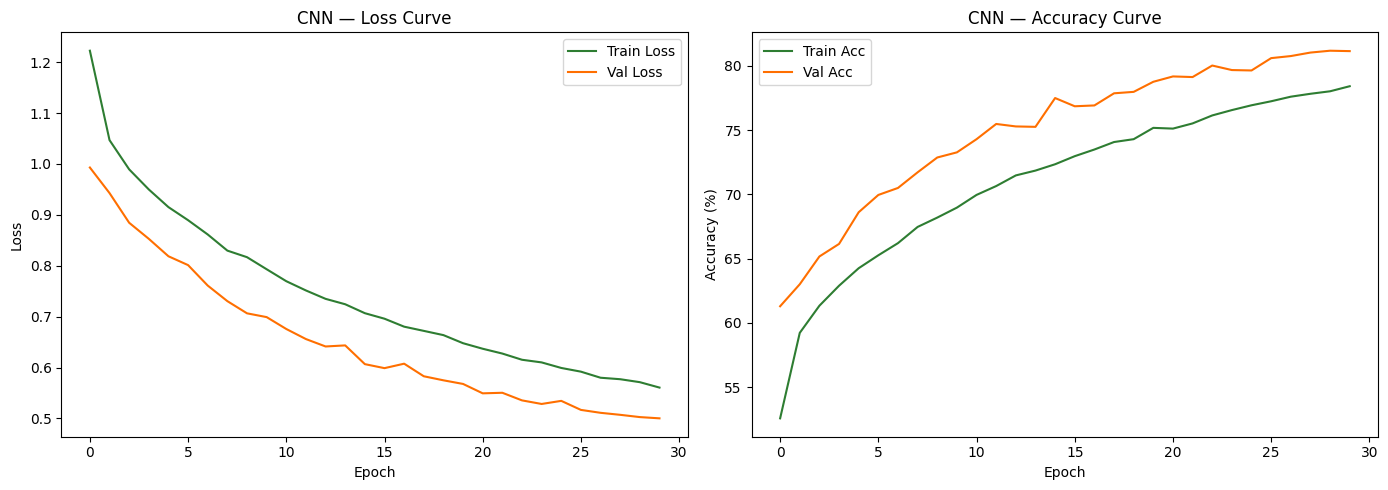

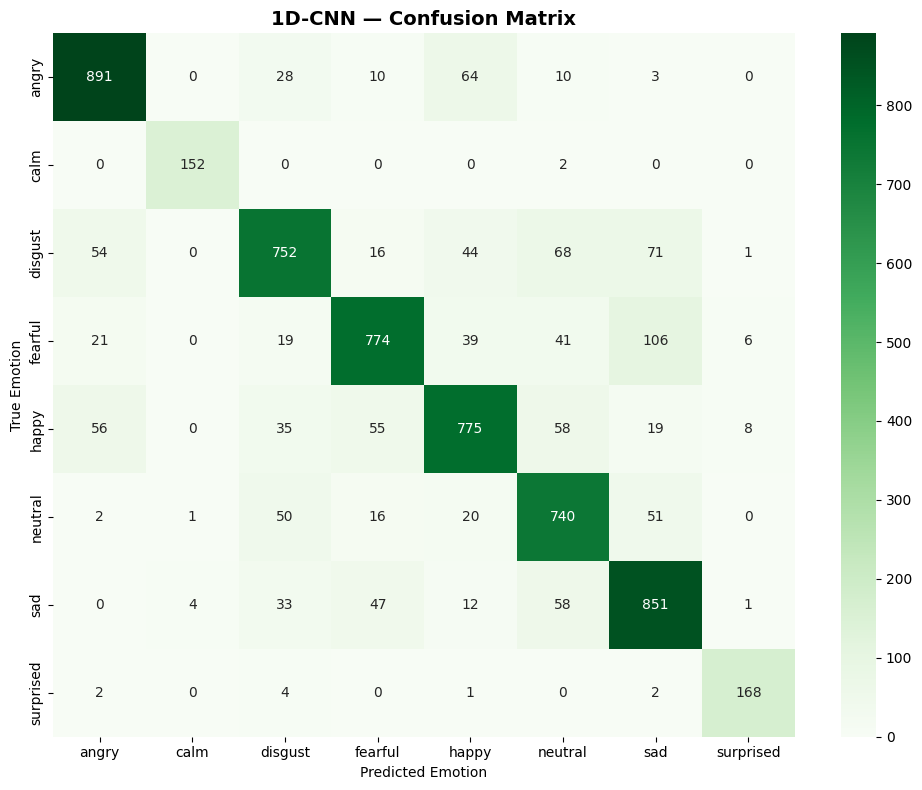

Section 5 outputs saved.
  ✓  cnn_model.pth
  ✓  cnn_training_curves.png
  ✓  cnn_confusion_matrix.png
  ✓  cnn_classification_report.csv
  ✓  cnn_results.json

  Accuracy    : 81.77%
  Weighted F1 : 0.8172


In [21]:
# ── 5.7 Plot Training History ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(cnn_history['train_loss'], label='Train Loss', color='#2e7d32')
axes[0].plot(cnn_history['val_loss'],   label='Val Loss',   color='#ff6f00')
axes[0].set_title('CNN — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy plot
axes[1].plot(cnn_history['train_acc'], label='Train Acc', color='#2e7d32')
axes[1].plot(cnn_history['val_acc'],   label='Val Acc',   color='#ff6f00')
axes[1].set_title('CNN — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/outputs/section5_cnn/cnn_training_curves.png', dpi=150)
plt.show()

# ── Confusion Matrix ──
cm_cnn = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cnn, annot=True, fmt='d', cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('1D-CNN — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.tight_layout()
plt.savefig('/kaggle/working/outputs/section5_cnn/cnn_confusion_matrix.png', dpi=150)
plt.show()

# ── Save Model ──
import json, pandas as pd
torch.save(best_model_state,
           '/kaggle/working/outputs/section5_cnn/cnn_model.pth')

# ── Save CSV Report ──
report_dict = classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    output_dict=True
)
pd.DataFrame(report_dict).transpose().to_csv(
    '/kaggle/working/outputs/section5_cnn/cnn_classification_report.csv'
)

# ── Save JSON Summary ──
summary_cnn = {
    'model'      : '1D-CNN',
    'section'    : 'Section 5',
    'accuracy'   : round(cnn_accuracy * 100, 2),
    'weighted_f1': round(cnn_f1, 4),
    'epochs'     : EPOCHS,
    'batch_size' : BATCH_SIZE,
    'optimizer'  : 'Adam',
    'lr'         : LR,
    'per_class'  : {
        cls: {
            'precision': round(report_dict[cls]['precision'], 4),
            'recall'   : round(report_dict[cls]['recall'],    4),
            'f1-score' : round(report_dict[cls]['f1-score'],  4)
        }
        for cls in le.classes_
    }
}
with open('/kaggle/working/outputs/section5_cnn/cnn_results.json', 'w') as f:
    json.dump(summary_cnn, f, indent=4)

print("Section 5 outputs saved.")
print("  ✓  cnn_model.pth")
print("  ✓  cnn_training_curves.png")
print("  ✓  cnn_confusion_matrix.png")
print("  ✓  cnn_classification_report.csv")
print("  ✓  cnn_results.json")
print(f"\n  Accuracy    : {cnn_accuracy * 100:.2f}%")
print(f"  Weighted F1 : {cnn_f1:.4f}")

## Section 6 — Deep Learning Model 2: CNN-LSTM
---
In this section we build a CNN-LSTM hybrid model.

What is CNN-LSTM?
- CNN part learns local patterns from the feature vector
- LSTM part learns how those patterns change over time
- Together they capture both the shape and the sequence of emotions in speech

Why is CNN-LSTM better than CNN alone?
- Emotions in speech are not just about what frequencies exist
- They also depend on HOW those frequencies change over time
- LSTM is specifically designed to learn these time-based patterns
- Combining both gives a much richer understanding of the speech signal

Expected accuracy: 88-92%
This should be better than our 1D-CNN result of 81.85%

In [22]:
# ─────────────────────────────────────────────
# SECTION 6 — CNN-LSTM MODEL
# ─────────────────────────────────────────────

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix)
import json
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── 6.1 Define CNN-LSTM Architecture ──

class CNNLSTM(nn.Module):
    def __init__(self, input_size, num_classes,
                 lstm_hidden=128, lstm_layers=2):
        super(CNNLSTM, self).__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.25)
        )

        # Calculate CNN output size
        self.cnn_out_size = input_size // 8

        # LSTM Temporal Modelling
        self.lstm = nn.LSTM(
            input_size  = 256,
            hidden_size = lstm_hidden,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = 0.3,
            bidirectional = False
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x shape: (batch, 1, features)

        # CNN extracts local patterns
        x = self.cnn(x)

        # Reshape for LSTM: (batch, seq_len, channels)
        x = x.permute(0, 2, 1)

        # LSTM learns temporal patterns
        lstm_out, _ = self.lstm(x)

        # Take last timestep output
        x = lstm_out[:, -1, :]

        # Classify
        x = self.classifier(x)
        return x


# Build model
NUM_CLASSES = len(le.classes_)
INPUT_SIZE  = X_train.shape[1]

cnnlstm_model = CNNLSTM(INPUT_SIZE, NUM_CLASSES).to(device)

print("CNN-LSTM Model Architecture:")
print(cnnlstm_model)

total_params = sum(p.numel() for p in cnnlstm_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Device: cuda
CNN-LSTM Model Architecture:
CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (lstm): LSTM(256, 1

In [23]:
# ── 6.2 Train CNN-LSTM ──

EPOCHS    = 30
LR        = 0.001
BATCH_SIZE = 64

# DataLoaders (reuse same splits)
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,
                          batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnnlstm_model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

cnnlstm_history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_loss     = float('inf')
best_model_state  = None

print(f"Training CNN-LSTM for {EPOCHS} epochs...")
print("-" * 60)

for epoch in range(EPOCHS):

    # ── Training ──
    cnnlstm_model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = cnnlstm_model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(cnnlstm_model.parameters(), 1.0)
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += len(y_batch)

    # ── Validation ──
    cnnlstm_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs     = cnnlstm_model(X_batch)
            loss        = criterion(outputs, y_batch)
            val_loss   += loss.item()
            preds       = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    # ── Metrics ──
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
    train_acc      = train_correct / train_total * 100
    val_acc        = val_correct   / val_total   * 100

    cnnlstm_history['train_loss'].append(avg_train_loss)
    cnnlstm_history['val_loss'].append(avg_val_loss)
    cnnlstm_history['train_acc'].append(train_acc)
    cnnlstm_history['val_acc'].append(val_acc)

    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        best_model_state = cnnlstm_model.state_dict().copy()

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

print("-" * 60)
print("Training complete.")
cnnlstm_model.load_state_dict(best_model_state)
print("Best model loaded.")

Training CNN-LSTM for 30 epochs...
------------------------------------------------------------
Epoch [01/30] Train Loss: 1.4703 Train Acc: 43.37% Val Loss: 1.1736 Val Acc: 54.98%
Epoch [02/30] Train Loss: 1.1557 Train Acc: 55.41% Val Loss: 1.0540 Val Acc: 58.69%
Epoch [03/30] Train Loss: 1.0598 Train Acc: 58.81% Val Loss: 0.9747 Val Acc: 61.40%
Epoch [04/30] Train Loss: 1.0034 Train Acc: 60.52% Val Loss: 0.9437 Val Acc: 63.00%
Epoch [05/30] Train Loss: 0.9665 Train Acc: 62.15% Val Loss: 0.9292 Val Acc: 63.61%
Epoch [06/30] Train Loss: 0.9344 Train Acc: 63.61% Val Loss: 0.8877 Val Acc: 64.54%
Epoch [07/30] Train Loss: 0.9039 Train Acc: 64.74% Val Loss: 0.8658 Val Acc: 66.06%
Epoch [08/30] Train Loss: 0.8822 Train Acc: 65.58% Val Loss: 0.8580 Val Acc: 66.18%
Epoch [09/30] Train Loss: 0.8563 Train Acc: 66.70% Val Loss: 0.8238 Val Acc: 67.73%
Epoch [10/30] Train Loss: 0.8380 Train Acc: 67.28% Val Loss: 0.7925 Val Acc: 68.85%
Epoch [11/30] Train Loss: 0.8171 Train Acc: 68.33% Val Loss: 0.7

In [24]:
# ── 6.3 Evaluate CNN-LSTM ──

cnnlstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = cnnlstm_model(X_batch)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

cnnlstm_accuracy = accuracy_score(all_labels, all_preds)
cnnlstm_f1       = f1_score(all_labels, all_preds, average='weighted')

print("=" * 45)
print("       CNN-LSTM RESULTS")
print("=" * 45)
print(f"  Accuracy        : {cnnlstm_accuracy * 100:.2f}%")
print(f"  Weighted F1     : {cnnlstm_f1:.4f}")
print("=" * 45)

print("\nPer-Class Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_
))

       CNN-LSTM RESULTS
  Accuracy        : 77.41%
  Weighted F1     : 0.7734

Per-Class Report:
              precision    recall  f1-score   support

       angry       0.82      0.88      0.85      1006
        calm       0.92      0.94      0.93       154
     disgust       0.74      0.72      0.73      1006
     fearful       0.78      0.72      0.75      1006
       happy       0.78      0.72      0.75      1006
     neutral       0.75      0.77      0.76       880
         sad       0.73      0.79      0.76      1006
   surprised       0.91      0.88      0.90       177

    accuracy                           0.77      6241
   macro avg       0.80      0.80      0.80      6241
weighted avg       0.77      0.77      0.77      6241



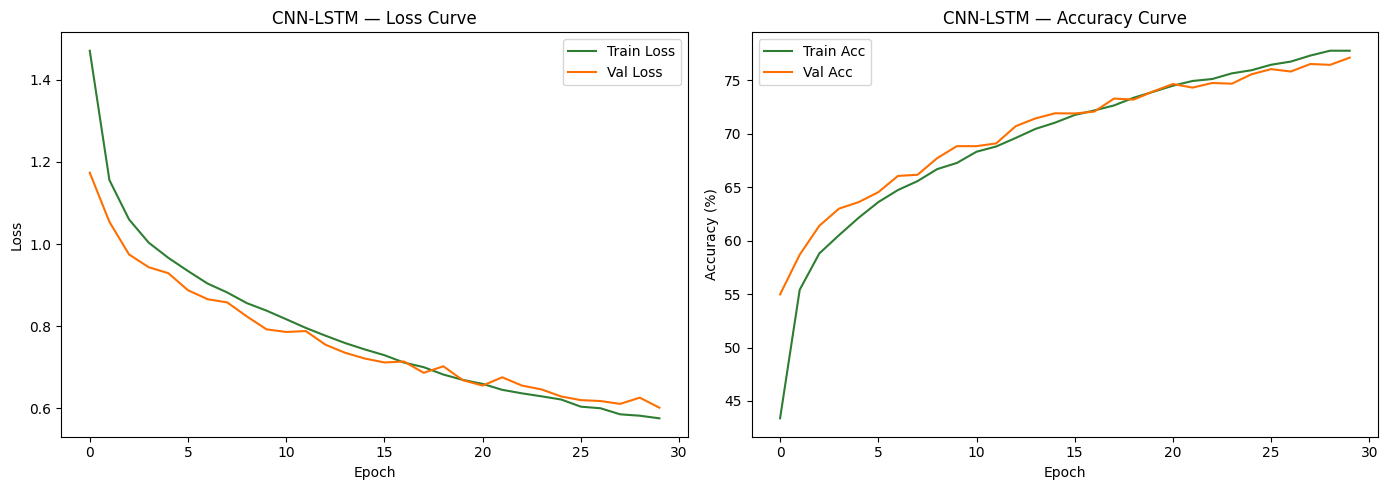

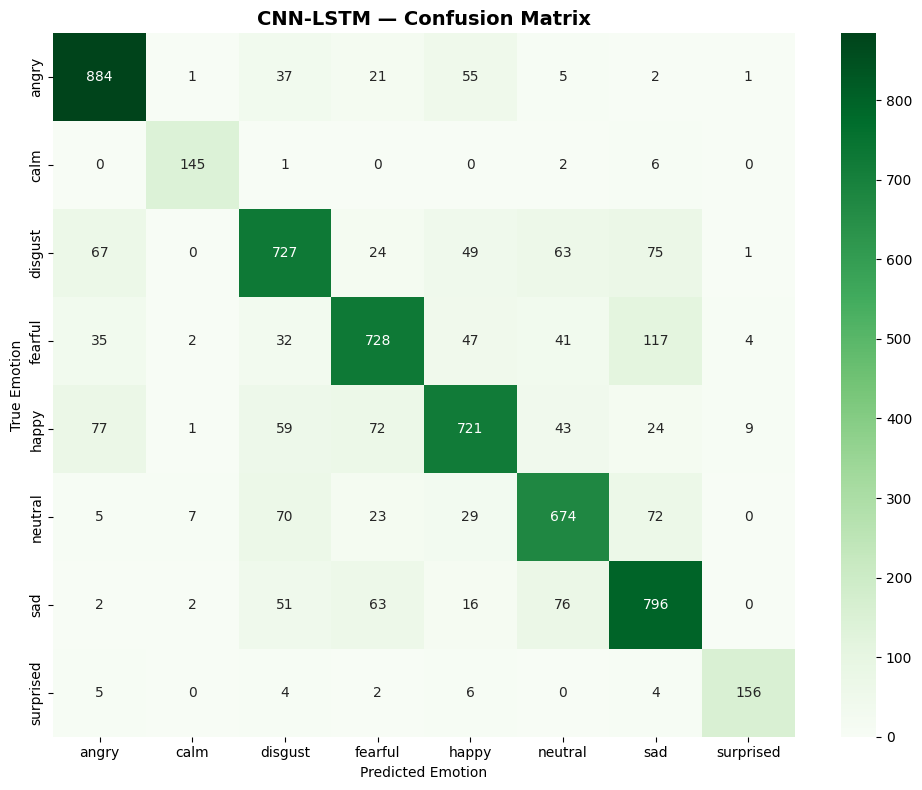

Section 6 outputs saved.
  ✓  cnnlstm_model.pth
  ✓  cnnlstm_training_curves.png
  ✓  cnnlstm_confusion_matrix.png
  ✓  cnnlstm_classification_report.csv
  ✓  cnnlstm_results.json

  Accuracy    : 77.41%
  Weighted F1 : 0.7734


In [25]:
# ── 6.4 Plot and Save Section 6 Outputs ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnnlstm_history['train_loss'],
             label='Train Loss', color='#2e7d32')
axes[0].plot(cnnlstm_history['val_loss'],
             label='Val Loss',   color='#ff6f00')
axes[0].set_title('CNN-LSTM — Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(cnnlstm_history['train_acc'],
             label='Train Acc', color='#2e7d32')
axes[1].plot(cnnlstm_history['val_acc'],
             label='Val Acc',   color='#ff6f00')
axes[1].set_title('CNN-LSTM — Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    '/kaggle/working/outputs/section6_cnn_lstm/cnnlstm_training_curves.png',
    dpi=150
)
plt.show()

# Confusion Matrix
cm_cnnlstm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_cnnlstm, annot=True, fmt='d', cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('CNN-LSTM — Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.tight_layout()
plt.savefig(
    '/kaggle/working/outputs/section6_cnn_lstm/cnnlstm_confusion_matrix.png',
    dpi=150
)
plt.show()

# Save model
torch.save(
    best_model_state,
    '/kaggle/working/outputs/section6_cnn_lstm/cnnlstm_model.pth'
)

# Save CSV report
report_dict = classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    output_dict=True
)
pd.DataFrame(report_dict).transpose().to_csv(
    '/kaggle/working/outputs/section6_cnn_lstm/cnnlstm_classification_report.csv'
)

# Save JSON summary
summary_cnnlstm = {
    'model'      : 'CNN-LSTM',
    'section'    : 'Section 6',
    'accuracy'   : round(cnnlstm_accuracy * 100, 2),
    'weighted_f1': round(cnnlstm_f1, 4),
    'epochs'     : EPOCHS,
    'batch_size' : BATCH_SIZE,
    'optimizer'  : 'Adam',
    'lr'         : LR,
    'per_class'  : {
        cls: {
            'precision': round(report_dict[cls]['precision'], 4),
            'recall'   : round(report_dict[cls]['recall'],    4),
            'f1-score' : round(report_dict[cls]['f1-score'],  4)
        }
        for cls in le.classes_
    }
}
with open(
    '/kaggle/working/outputs/section6_cnn_lstm/cnnlstm_results.json', 'w'
) as f:
    json.dump(summary_cnnlstm, f, indent=4)

print("Section 6 outputs saved.")
print("  ✓  cnnlstm_model.pth")
print("  ✓  cnnlstm_training_curves.png")
print("  ✓  cnnlstm_confusion_matrix.png")
print("  ✓  cnnlstm_classification_report.csv")
print("  ✓  cnnlstm_results.json")
print(f"\n  Accuracy    : {cnnlstm_accuracy * 100:.2f}%")
print(f"  Weighted F1 : {cnnlstm_f1:.4f}")

## Section 7 — Main Contribution: CNN1D with Channel and Spatial Attention
---
This is the main novel model of this project.
 
Building on the 1D-CNN architecture from Section 5, we add two attention
mechanisms after every convolutional block:
 
- **Channel Attention** learns which feature channels are most important for
  emotion classification (squeeze-and-excitation style: global average pooling,
  a bottleneck MLP, and a sigmoid gate).
- **Spatial Attention** learns which positions within the feature map carry the
  most emotionally relevant information (mean and max across channels, a
  convolution, and a sigmoid gate).
 
The model is trained for 70 epochs with the Adam optimizer, a
ReduceLROnPlateau schedule, and checkpointing on the best validation loss.
Training uses a fixed random seed so the run is reproducible. The exact
results are printed by the evaluation cell below and saved to JSON; every
summary table later in this notebook reads from those saved files.


In [26]:
 #─────────────────────────────────────────────────────────────────
# [CODE] CELL 7.1 — Load features, recreate the split, build loaders
# ─────────────────────────────────────────────────────────────────
import os, glob, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
 
S7_OUT = '/kaggle/working/outputs/section7_attention'
S8_OUT = '/kaggle/working/outputs/section8_ablation'
os.makedirs(S7_OUT, exist_ok=True)
os.makedirs(S8_OUT, exist_ok=True)
 
def find_file(name):
    """Look in current working outputs first, then any attached input."""
    candidates = [f'/kaggle/working/outputs/section3_features/{name}']
    candidates += glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    for c in candidates:
        if os.path.exists(c):
            print(f'Loading {name} from: {c}')
            return c
    raise FileNotFoundError(f'{name} not found.')
 
X = np.load(find_file('X_scaled.npy'))
y_enc = np.load(find_file('y_encoded.npy'))
y_lab = np.load(find_file('y_labels.npy'), allow_pickle=True)
le = LabelEncoder(); le.fit(y_lab)
CLASSES = list(le.classes_)
print('Features:', X.shape, '| Classes:', CLASSES)
 
# Identical two-stage stratified split, seed 42 (same as Sections 4-6)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f'Split -> train {len(X_train)}, val {len(X_val)}, test {len(X_test)}')
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
def make_loader(Xa, ya, shuffle):
    ds = TensorDataset(torch.tensor(Xa, dtype=torch.float32).unsqueeze(1),
                       torch.tensor(ya, dtype=torch.long))
    return DataLoader(ds, batch_size=64, shuffle=shuffle,
                      num_workers=2, pin_memory=True)
 
train_loader = make_loader(X_train, y_train, True)
val_loader   = make_loader(X_val,   y_val,   False)
test_loader  = make_loader(X_test,  y_test,  False)

Loading X_scaled.npy from: /kaggle/working/outputs/section3_features/X_scaled.npy
Loading y_encoded.npy from: /kaggle/working/outputs/section3_features/y_encoded.npy
Loading y_labels.npy from: /kaggle/working/outputs/section3_features/y_labels.npy
Features: (62408, 234) | Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
Split -> train 49926, val 6241, test 6241


In [27]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 7.2 — Attention modules and the model (with ablation flags)
# ─────────────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Squeeze-and-excitation style channel attention for 1D feature maps."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid())
    def forward(self, x):
        w = self.mlp(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w
 
class SpatialAttention(nn.Module):
    """CBAM-style spatial attention for 1D feature maps."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv1d(2, 1, kernel_size, padding=kernel_size // 2)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        w = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * w
 
class AttentionCNN(nn.Module):
    """3-block 1D-CNN; channel/spatial attention optionally after each block.
    With both flags True this is the proposed final model. With both False it
    is architecturally the plain 1D-CNN of Section 5."""
    def __init__(self, n_classes=8, use_channel=True, use_spatial=True):
        super().__init__()
        self.use_channel, self.use_spatial = use_channel, use_spatial
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv1d(cin, cout, 3, padding=1), nn.BatchNorm1d(cout),
                nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.25))
        self.b1, self.b2, self.b3 = block(1, 64), block(64, 128), block(128, 256)
        if use_channel:
            self.ca1, self.ca2, self.ca3 = (ChannelAttention(c) for c in (64, 128, 256))
        if use_spatial:
            self.sa1, self.sa2, self.sa3 = (SpatialAttention() for _ in range(3))
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(256 * 29, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, n_classes))
    def forward(self, x):
        for b, ca, sa in ((self.b1,'ca1','sa1'), (self.b2,'ca2','sa2'), (self.b3,'ca3','sa3')):
            x = b(x)
            if self.use_channel: x = getattr(self, ca)(x)
            if self.use_spatial: x = getattr(self, sa)(x)
        return self.head(x)
 


In [28]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 7.3 — Training function (seeded, saves ckpt/results/history)
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, classification_report
 
def train_config(name, out_dir, use_channel, use_spatial, epochs=70, seed=42):
    seed_everything(seed)   # reproducible run
    model = AttentionCNN(use_channel=use_channel, use_spatial=use_spatial).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n=== {name} | params: {n_params:,} | seed {seed} ===')
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=4)
    crit = nn.CrossEntropyLoss()
    best_val, ckpt = float('inf'), f'{out_dir}/{name}.pth'
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
 
    for ep in range(1, epochs + 1):
        model.train(); tl = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb)
            loss.backward(); opt.step(); tl += loss.item() * len(xb)
        model.eval(); vl, preds, trues = 0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb); vl += crit(out, yb).item() * len(xb)
                preds += out.argmax(1).cpu().tolist(); trues += yb.cpu().tolist()
        tl /= len(X_train); vl /= len(X_val)
        va = accuracy_score(trues, preds) * 100
        history['train_loss'].append(round(tl, 4))
        history['val_loss'].append(round(vl, 4))
        history['val_acc'].append(round(va, 2))
        sched.step(vl)
        if vl < best_val:
            best_val = vl; torch.save(model.state_dict(), ckpt)
        if ep % 5 == 0 or ep == 1:
            print(f'ep {ep:3d} | train_loss {tl:.4f} | val_loss {vl:.4f} | val_acc {va:.2f}%')
 
    # Evaluate the best checkpoint on the test set (used exactly once)
    model.load_state_dict(torch.load(ckpt)); model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds += model(xb.to(device)).argmax(1).cpu().tolist()
            trues += yb.tolist()
    acc = accuracy_score(trues, preds) * 100
    f1w = f1_score(trues, preds, average='weighted')
    print(f'{name} TEST: acc {acc:.2f}% | weighted F1 {f1w:.4f}')
 
    report = classification_report(trues, preds, target_names=CLASSES, output_dict=True)
    res = {'config': name, 'params': n_params, 'seed': seed, 'epochs': epochs,
           'accuracy': round(acc, 2), 'weighted_f1': round(f1w, 4),
           'per_class': {c: {'precision': round(report[c]['precision'], 4),
                             'recall':    round(report[c]['recall'], 4),
                             'f1-score':  round(report[c]['f1-score'], 4)} for c in CLASSES}}
    with open(f'{out_dir}/{name}_results.json', 'w') as f:
        json.dump(res, f, indent=2)
    with open(f'{out_dir}/{name}_history.json', 'w') as f:
        json.dump(history, f)
    with open(f'{out_dir}/{name}_report.txt', 'w') as f:
        f.write(classification_report(trues, preds, target_names=CLASSES))
    return res
 


In [29]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 7.4 — Train the FINAL model (channel + spatial, 70 epochs)
# ─────────────────────────────────────────────────────────────────
res_final = train_config('final_attention_model', S7_OUT,
                         use_channel=True, use_spatial=True)


=== final_attention_model | params: 2,081,197 | seed 42 ===
ep   1 | train_loss 1.1963 | val_loss 0.9688 | val_acc 62.51%
ep   5 | train_loss 0.8700 | val_loss 0.7865 | val_acc 70.04%
ep  10 | train_loss 0.7317 | val_loss 0.6458 | val_acc 75.58%
ep  15 | train_loss 0.6372 | val_loss 0.5788 | val_acc 77.68%
ep  20 | train_loss 0.5751 | val_loss 0.5334 | val_acc 79.55%
ep  25 | train_loss 0.5239 | val_loss 0.4933 | val_acc 81.38%
ep  30 | train_loss 0.4757 | val_loss 0.4738 | val_acc 82.26%
ep  35 | train_loss 0.4447 | val_loss 0.4675 | val_acc 83.08%
ep  40 | train_loss 0.4165 | val_loss 0.4662 | val_acc 83.58%
ep  45 | train_loss 0.3907 | val_loss 0.4303 | val_acc 85.07%
ep  50 | train_loss 0.3703 | val_loss 0.4556 | val_acc 83.53%
ep  55 | train_loss 0.3289 | val_loss 0.4167 | val_acc 85.80%
ep  60 | train_loss 0.2988 | val_loss 0.4232 | val_acc 85.85%
ep  65 | train_loss 0.2875 | val_loss 0.4273 | val_acc 86.00%
ep  70 | train_loss 0.2764 | val_loss 0.4224 | val_acc 86.28%
final_att

              precision    recall  f1-score   support

       angry       0.91      0.92      0.91      1006
        calm       0.99      0.99      0.99       154
     disgust       0.84      0.83      0.84      1006
     fearful       0.89      0.82      0.85      1006
       happy       0.83      0.88      0.85      1006
     neutral       0.83      0.89      0.86       880
         sad       0.88      0.83      0.86      1006
   surprised       0.97      0.97      0.97       177

    accuracy                           0.87      6241
   macro avg       0.89      0.89      0.89      6241
weighted avg       0.87      0.87      0.87      6241



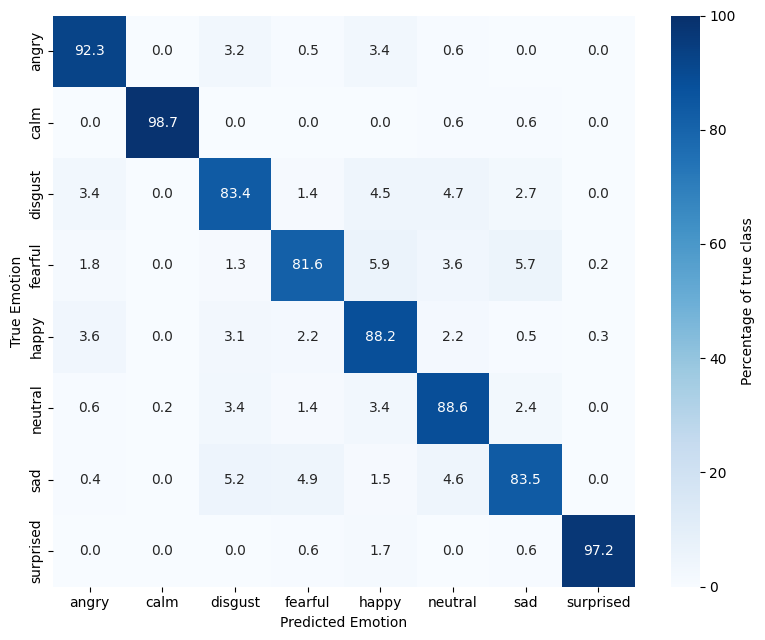

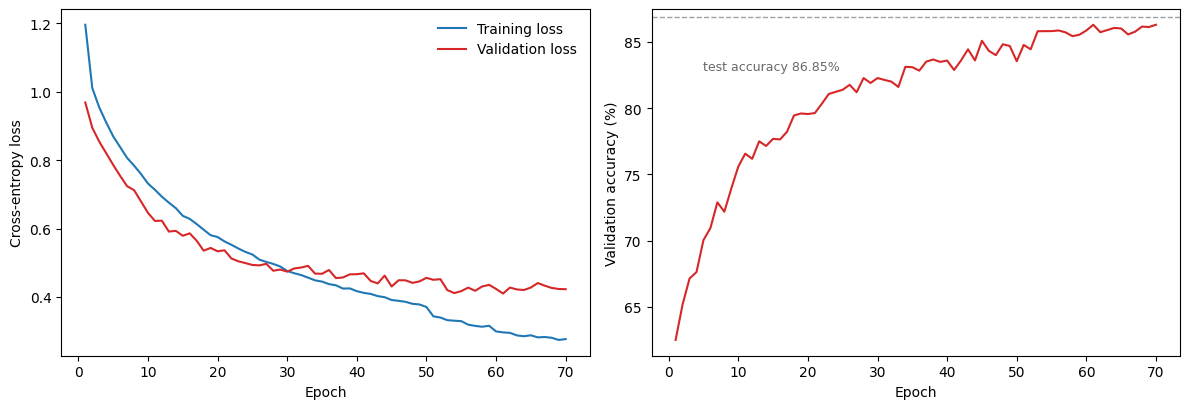

Section 7 outputs saved to /kaggle/working/outputs/section7_attention


In [30]:
 
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 7.5 — Evaluate final model: report, confusion matrix, curves
# ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
 
# Reload best checkpoint and predict (kept for the confusion matrix)
model_final = AttentionCNN(use_channel=True, use_spatial=True).to(device)
model_final.load_state_dict(torch.load(f'{S7_OUT}/final_attention_model.pth'))
model_final.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds += model_final(xb.to(device)).argmax(1).cpu().tolist()
        all_labels += yb.tolist()
 
print(classification_report(all_labels, all_preds, target_names=CLASSES))
 
# Confusion matrix (row-normalised so minority classes are readable)
cm = confusion_matrix(all_labels, all_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
plt.figure(figsize=(8, 6.5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            cbar_kws={'label': 'Percentage of true class'},
            xticklabels=CLASSES, yticklabels=CLASSES, vmin=0, vmax=100)
plt.xlabel('Predicted Emotion'); plt.ylabel('True Emotion')
plt.tight_layout()
plt.savefig(f'{S7_OUT}/final_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
 
# Training curves from the saved history (full 70 points)
hist = json.load(open(f'{S7_OUT}/final_attention_model_history.json'))
ep = range(1, len(hist['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(ep, hist['train_loss'], color='#1f77b4', label='Training loss')
axes[0].plot(ep, hist['val_loss'], color='#d62728', label='Validation loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend(frameon=False)
axes[1].plot(ep, hist['val_acc'], color='#d62728')
axes[1].axhline(res_final['accuracy'], color='#9aa0a6', ls='--', lw=1)
axes[1].annotate(f"test accuracy {res_final['accuracy']}%",
                 xy=(5, res_final['accuracy']), xytext=(5, res_final['accuracy'] - 4),
                 fontsize=9, color='dimgrey')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy (%)')
plt.tight_layout()
plt.savefig(f'{S7_OUT}/final_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Section 7 outputs saved to', S7_OUT)


## Section 8 — Ablation Study (Objective 5)
---
To isolate the contribution of each attention component, this section retrains
the Section 7 architecture in two reduced configurations under the identical
protocol (same split, same seed, same optimizer, schedule, batch size, epochs,
and checkpointing):
 
1. **Channel attention only**
2. **Spatial attention only**
 
Together with the plain 1D-CNN from Section 5 (no attention) and the full
model from Section 7 (both components), this gives a four-row ablation. The
table at the end of this section is built by reading the saved results files
of all four runs, so it always reflects the training logs exactly.

In [31]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 8.1 — Channel attention only (~45 min)
# ─────────────────────────────────────────────────────────────────
res_channel = train_config('ablation_channel_only', S8_OUT,
                           use_channel=True, use_spatial=False)


=== ablation_channel_only | params: 2,081,152 | seed 42 ===
ep   1 | train_loss 1.1943 | val_loss 0.9693 | val_acc 62.31%
ep   5 | train_loss 0.8748 | val_loss 0.7833 | val_acc 69.84%
ep  10 | train_loss 0.7361 | val_loss 0.6534 | val_acc 74.60%
ep  15 | train_loss 0.6465 | val_loss 0.5870 | val_acc 77.89%
ep  20 | train_loss 0.5810 | val_loss 0.5200 | val_acc 80.90%
ep  25 | train_loss 0.5296 | val_loss 0.4848 | val_acc 82.23%
ep  30 | train_loss 0.4944 | val_loss 0.4648 | val_acc 83.18%
ep  35 | train_loss 0.4631 | val_loss 0.4379 | val_acc 84.25%
ep  40 | train_loss 0.4304 | val_loss 0.4289 | val_acc 84.54%
ep  45 | train_loss 0.4078 | val_loss 0.4181 | val_acc 84.67%
ep  50 | train_loss 0.3911 | val_loss 0.4052 | val_acc 85.72%
ep  55 | train_loss 0.3719 | val_loss 0.3891 | val_acc 86.16%
ep  60 | train_loss 0.3535 | val_loss 0.3826 | val_acc 86.54%
ep  65 | train_loss 0.3430 | val_loss 0.3757 | val_acc 87.04%
ep  70 | train_loss 0.3252 | val_loss 0.3631 | val_acc 87.01%
ablation_

In [32]:
 
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 8.2 — Spatial attention only (~45 min)
# ─────────────────────────────────────────────────────────────────
res_spatial = train_config('ablation_spatial_only', S8_OUT,
                           use_channel=False, use_spatial=True)


=== ablation_spatial_only | params: 2,059,189 | seed 42 ===
ep   1 | train_loss 1.2139 | val_loss 0.9865 | val_acc 61.51%
ep   5 | train_loss 0.9152 | val_loss 0.8251 | val_acc 68.08%
ep  10 | train_loss 0.7971 | val_loss 0.7106 | val_acc 72.78%
ep  15 | train_loss 0.7149 | val_loss 0.6179 | val_acc 76.33%
ep  20 | train_loss 0.6475 | val_loss 0.5674 | val_acc 78.40%
ep  25 | train_loss 0.5946 | val_loss 0.5279 | val_acc 80.28%
ep  30 | train_loss 0.5520 | val_loss 0.4939 | val_acc 81.51%
ep  35 | train_loss 0.5200 | val_loss 0.4677 | val_acc 82.65%
ep  40 | train_loss 0.4905 | val_loss 0.4555 | val_acc 83.00%
ep  45 | train_loss 0.4667 | val_loss 0.4418 | val_acc 83.69%
ep  50 | train_loss 0.4436 | val_loss 0.4308 | val_acc 84.25%
ep  55 | train_loss 0.4300 | val_loss 0.4122 | val_acc 84.86%
ep  60 | train_loss 0.4099 | val_loss 0.4143 | val_acc 85.77%
ep  65 | train_loss 0.3718 | val_loss 0.3890 | val_acc 86.33%
ep  70 | train_loss 0.3598 | val_loss 0.3838 | val_acc 86.38%
ablation_

In [33]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 8.3 — Ablation table (dynamic: reads saved results)
# ─────────────────────────────────────────────────────────────────
import pandas as pd
 
def load_json(path):
    with open(path) as f:
        return json.load(f)
 
cnn_res  = load_json('/kaggle/working/outputs/section5_cnn/cnn_results.json')
ch_res   = load_json(f'{S8_OUT}/ablation_channel_only_results.json')
sp_res   = load_json(f'{S8_OUT}/ablation_spatial_only_results.json')
full_res = load_json(f'{S7_OUT}/final_attention_model_results.json')
 
ablation = pd.DataFrame([
    {'Configuration': 'No attention (1D-CNN, Section 5)', 'Params': 2_059_144,
     'Accuracy %': cnn_res['accuracy'],  'Weighted F1': cnn_res['weighted_f1']},
    {'Configuration': 'Spatial attention only',           'Params': sp_res['params'],
     'Accuracy %': sp_res['accuracy'],   'Weighted F1': sp_res['weighted_f1']},
    {'Configuration': 'Channel attention only',           'Params': ch_res['params'],
     'Accuracy %': ch_res['accuracy'],   'Weighted F1': ch_res['weighted_f1']},
    {'Configuration': 'Channel + Spatial (FINAL MODEL)',  'Params': full_res['params'],
     'Accuracy %': full_res['accuracy'], 'Weighted F1': full_res['weighted_f1']},
])
print('ABLATION STUDY — identical protocol for all configurations')
print(ablation.to_string(index=False))
ablation.to_csv(f'{S8_OUT}/ablation_table.csv', index=False)

ABLATION STUDY — identical protocol for all configurations
                   Configuration  Params  Accuracy %  Weighted F1
No attention (1D-CNN, Section 5) 2059144       81.77       0.8172
          Spatial attention only 2059189       86.67       0.8671
          Channel attention only 2081152       88.06       0.8807
 Channel + Spatial (FINAL MODEL) 2081197       86.85       0.8683


## Section 9 — Final Results Comparison and Benchmarking
---
This final section brings together the results of all four models under the
single evaluation protocol (same features, same split, same test set used once
per model), benchmarks the final model against published state-of-the-art
methods from the literature review, and generates the figures used in the
dissertation. Every table and chart below reads the saved results files, so
the reported numbers always match the training logs above.


In [34]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 9.1 — Summary table of all four models (dynamic)
# ─────────────────────────────────────────────────────────────────
FINAL_OUT = '/kaggle/working/outputs/section9_final'
os.makedirs(FINAL_OUT, exist_ok=True)
 
svm_res  = load_json('/kaggle/working/outputs/section4_svm/svm_results.json')
lstm_res = load_json('/kaggle/working/outputs/section6_cnn_lstm/cnnlstm_results.json')
 
comparison = pd.DataFrame([
    {'Model': 'SVM (RBF baseline)',                           'Parameters': None,
     'Accuracy %': svm_res['accuracy'],  'Weighted F1': svm_res['weighted_f1']},
    {'Model': '1D-CNN',                                       'Parameters': 2_059_144,
     'Accuracy %': cnn_res['accuracy'],  'Weighted F1': cnn_res['weighted_f1']},
    {'Model': 'CNN-LSTM',                                     'Parameters': 471_688,
     'Accuracy %': lstm_res['accuracy'], 'Weighted F1': lstm_res['weighted_f1']},
    {'Model': '1D-CNN + Channel & Spatial Attention (FINAL)', 'Parameters': full_res['params'],
     'Accuracy %': full_res['accuracy'], 'Weighted F1': full_res['weighted_f1']},
])
print('=' * 78)
print('               FINAL MODEL COMPARISON — IDENTICAL PROTOCOL')
print('=' * 78)
print(comparison.to_string(index=False))
print('=' * 78)
print(f"Improvement over SVM baseline : +{full_res['accuracy'] - svm_res['accuracy']:.2f} percentage points")
print(f"Improvement over plain 1D-CNN : +{full_res['accuracy'] - cnn_res['accuracy']:.2f} percentage points")
comparison.to_csv(f'{FINAL_OUT}/model_comparison.csv', index=False)


               FINAL MODEL COMPARISON — IDENTICAL PROTOCOL
                                       Model  Parameters  Accuracy %  Weighted F1
                          SVM (RBF baseline)         NaN       75.12       0.7508
                                      1D-CNN   2059144.0       81.77       0.8172
                                    CNN-LSTM    471688.0       77.41       0.7734
1D-CNN + Channel & Spatial Attention (FINAL)   2081197.0       86.85       0.8683
Improvement over SVM baseline : +11.73 percentage points
Improvement over plain 1D-CNN : +5.08 percentage points


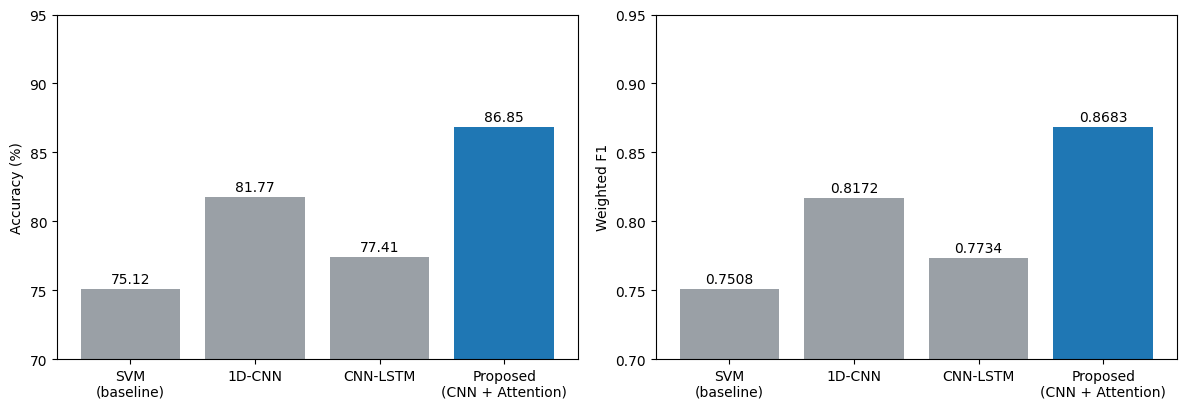

In [35]:
 
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 9.2 — Model comparison chart (dynamic; thesis Figure 4.3)
# ─────────────────────────────────────────────────────────────────
BLUE, GREY = '#1f77b4', '#9aa0a6'
models = ['SVM\n(baseline)', '1D-CNN', 'CNN-LSTM', 'Proposed\n(CNN + Attention)']
accs = [svm_res['accuracy'], cnn_res['accuracy'], lstm_res['accuracy'], full_res['accuracy']]
f1s  = [svm_res['weighted_f1'], cnn_res['weighted_f1'], lstm_res['weighted_f1'], full_res['weighted_f1']]
colors = [GREY, GREY, GREY, BLUE]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
b0 = axes[0].bar(models, accs, color=colors)
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(70, 95)
axes[0].bar_label(b0, fmt='%.2f', padding=2)
b1 = axes[1].bar(models, f1s, color=colors)
axes[1].set_ylabel('Weighted F1'); axes[1].set_ylim(0.70, 0.95)
axes[1].bar_label(b1, fmt='%.4f', padding=2)
plt.tight_layout()
plt.savefig(f'{FINAL_OUT}/fig4_3_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
 


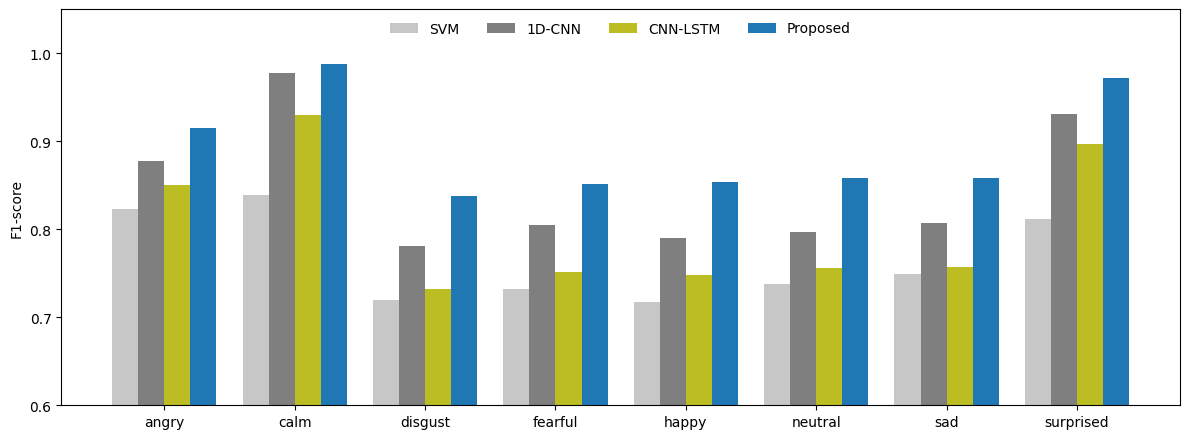

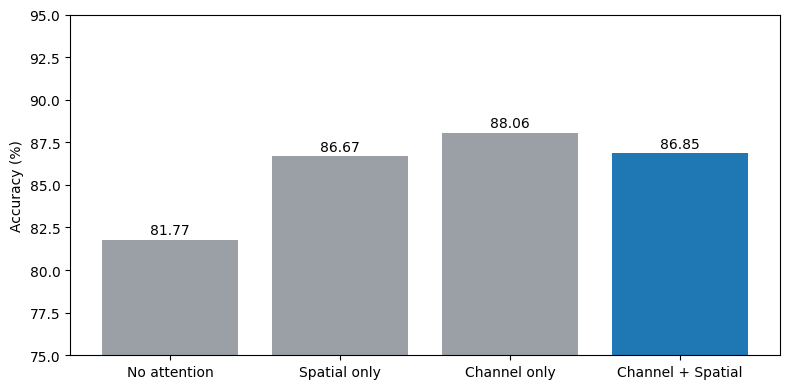

In [36]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 9.3 — Per-class F1 chart + ablation chart (dynamic)
# ─────────────────────────────────────────────────────────────────
x = np.arange(len(CLASSES)); w = 0.2
f1_svm  = [svm_res['per_class'][c]['f1-score']  for c in CLASSES]
f1_cnn  = [cnn_res['per_class'][c]['f1-score']  for c in CLASSES]
f1_lstm = [lstm_res['per_class'][c]['f1-score'] for c in CLASSES]
f1_att  = [full_res['per_class'][c]['f1-score'] for c in CLASSES]
plt.figure(figsize=(12, 4.5))
plt.bar(x - 1.5*w, f1_svm,  w, label='SVM',      color='#c7c7c7')
plt.bar(x - 0.5*w, f1_cnn,  w, label='1D-CNN',   color='#7f7f7f')
plt.bar(x + 0.5*w, f1_lstm, w, label='CNN-LSTM', color='#bcbd22')
plt.bar(x + 1.5*w, f1_att,  w, label='Proposed', color=BLUE)
plt.xticks(x, CLASSES); plt.ylabel('F1-score'); plt.ylim(0.6, 1.05)
plt.legend(frameon=False, ncol=4, loc='upper center')
plt.tight_layout()
plt.savefig(f'{FINAL_OUT}/fig4_4_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()
 
# Ablation chart (optional thesis Figure 4.5)
configs = ['No attention', 'Spatial only', 'Channel only', 'Channel + Spatial']
ab_acc  = [cnn_res['accuracy'], sp_res['accuracy'], ch_res['accuracy'], full_res['accuracy']]
plt.figure(figsize=(8, 4))
b = plt.bar(configs, ab_acc, color=[GREY, GREY, GREY, BLUE])
plt.bar_label(b, fmt='%.2f', padding=2)
plt.ylabel('Accuracy (%)'); plt.ylim(75, 95)
plt.tight_layout()
plt.savefig(f'{FINAL_OUT}/fig4_5_ablation.png', dpi=300, bbox_inches='tight')
plt.show()
 


In [37]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 9.4 — Benchmark vs published methods (project row dynamic)
# ─────────────────────────────────────────────────────────────────
# figure (in particular the DCRF-BiLSTM result attributed to Ben-Sauod [11]).
benchmark = pd.DataFrame([
    {'Study': 'Singh et al. [4]',     'Method': '2D-CNN + LSTM + self-attention',       'Datasets': 'RAVDESS + TESS + SAVEE',                   'Reported Accuracy %': 90.00},
    {'Study': 'Mishra et al. [5]',    'Method': 'Hybrid CNN-BiLSTM',                    'Datasets': 'Multi-speaker (RAVDESS/CREMA-D)',           'Reported Accuracy %': 89.00},
    {'Study': 'Ben-Sauod [11]',       'Method': 'DCRF-BiLSTM',                          'Datasets': 'RAVDESS + TESS + SAVEE + CREMA-D + EMO-DB', 'Reported Accuracy %': 98.82},
    {'Study': 'This project (FINAL)', 'Method': '1D-CNN + Channel & Spatial Attention', 'Datasets': 'RAVDESS + CREMA-D + TESS + SAVEE',          'Reported Accuracy %': full_res['accuracy']},
])
print(benchmark.to_string(index=False))
print('Note: published figures come from differing corpora combinations and')
print('evaluation protocols; direct comparison is indicative, not exact.')
benchmark.to_csv(f'{FINAL_OUT}/benchmark_comparison.csv', index=False)
 


               Study                               Method                                  Datasets  Reported Accuracy %
    Singh et al. [4]       2D-CNN + LSTM + self-attention                    RAVDESS + TESS + SAVEE                90.00
   Mishra et al. [5]                    Hybrid CNN-BiLSTM           Multi-speaker (RAVDESS/CREMA-D)                89.00
      Ben-Sauod [11]                          DCRF-BiLSTM RAVDESS + TESS + SAVEE + CREMA-D + EMO-DB                98.82
This project (FINAL) 1D-CNN + Channel & Spatial Attention          RAVDESS + CREMA-D + TESS + SAVEE                86.85
Note: published figures come from differing corpora combinations and
evaluation protocols; direct comparison is indicative, not exact.


In [38]:
# ─────────────────────────────────────────────────────────────────
# [CODE] CELL 9.5 — Final project summary (fully dynamic)
# ─────────────────────────────────────────────────────────────────
final_summary = {
    'project_title': 'Speech Emotion Recognition Using Machine Learning',
    'datasets_used': ['RAVDESS', 'CREMA-D', 'TESS', 'SAVEE'],
    'original_files': 15602,
    'total_samples_after_augmentation': 62408,
    'features_per_sample': 234,
    'random_seed': 42,
    'models_evaluated': {
        'SVM Baseline':              {'accuracy': svm_res['accuracy'],  'weighted_f1': svm_res['weighted_f1']},
        '1D-CNN':                    {'accuracy': cnn_res['accuracy'],  'weighted_f1': cnn_res['weighted_f1']},
        'CNN-LSTM':                  {'accuracy': lstm_res['accuracy'], 'weighted_f1': lstm_res['weighted_f1']},
        'CNN1D + Attention (FINAL)': {'accuracy': full_res['accuracy'], 'weighted_f1': full_res['weighted_f1']},
    },
    'ablation_study': {
        'no_attention': {'accuracy': cnn_res['accuracy'], 'weighted_f1': cnn_res['weighted_f1']},
        'spatial_only': {'accuracy': sp_res['accuracy'],  'weighted_f1': sp_res['weighted_f1']},
        'channel_only': {'accuracy': ch_res['accuracy'],  'weighted_f1': ch_res['weighted_f1']},
        'channel_plus_spatial_final': {'accuracy': full_res['accuracy'], 'weighted_f1': full_res['weighted_f1']},
    },
    'final_model': 'CNN1D + Channel and Spatial Attention (Section 7)',
    'final_checkpoint': 'outputs/section7_attention/final_attention_model.pth',
    'best_accuracy': full_res['accuracy'],
    'best_weighted_f1': full_res['weighted_f1'],
    'improvement_over_baseline_pct_points': round(full_res['accuracy'] - svm_res['accuracy'], 2),
}
with open(f'{FINAL_OUT}/final_project_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=4)
 
print('=' * 60)
print('PROJECT COMPLETE')
print(f"Final Accuracy: {full_res['accuracy']}%  |  Weighted F1: {full_res['weighted_f1']}")
print(f"Improvement over SVM baseline: +{full_res['accuracy'] - svm_res['accuracy']:.2f} percentage points")
print('=' * 60)

PROJECT COMPLETE
Final Accuracy: 86.85%  |  Weighted F1: 0.8683
Improvement over SVM baseline: +11.73 percentage points
